# Full 15.4M Dataset Training: XGBoost + LightGBM Ensemble
Trained on all **15,399,977 pairs** with Apple Silicon multi-core acceleration and **Macro $F_{0.5}$** optimization.


In [1]:
import os
import re
import time
import gc
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, roc_auc_score, f1_score
from rapidfuzz import fuzz
import lightgbm as lgb
import xgboost as xgb

# Apple Silicon hardware check
mps_available = torch.backends.mps.is_available()
num_cpus = os.cpu_count()
print(f"Hardware Acceleration: Apple Silicon {num_cpus}-Core CPU | PyTorch MPS: {mps_available}")
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')


Hardware Acceleration: Apple Silicon 10-Core CPU | PyTorch MPS: True


## 1. Load Extracted 15.4M Feature Matrix
Fast binary cache loading (`~554 MB` RAM).


In [2]:
features_cache_path = 'models/features_15m.npy'
labels_cache_path = 'models/labels_15m.npy'

t0 = time.time()
X = np.load(features_cache_path)
y = np.load(labels_cache_path)
print(f"Loaded 15.4M feature matrix in {time.time()-t0:.2f}s")
print(f"X shape: {X.shape} ({X.nbytes / 1e6:.1f} MB) | y shape: {y.shape} ({y.nbytes / 1e6:.1f} MB)")
print(f"Class Balance: {np.mean(y == 1)*100:.2f}% Positives, {np.mean(y == 0)*100:.2f}% Negatives")


Loaded 15.4M feature matrix in 0.08s
X shape: (15399977, 9) (554.4 MB) | y shape: (15399977,) (15.4 MB)
Class Balance: 49.60% Positives, 50.40% Negatives


## 2. Train / Validation Split (85% / 15%)
Stratified split: 13,089,980 training pairs and 2,309,997 validation pairs.


In [3]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
print(f"Train samples: {X_train.shape[0]:,} | Validation samples: {X_val.shape[0]:,}")


Train samples: 13,089,980 | Validation samples: 2,309,997


## 3. Train LightGBM on 13.1M Pairs
Histogram gradient boosting across Apple Silicon CPU cores.


In [4]:
t0 = time.time()
lgb_model = lgb.LGBMClassifier(
    n_estimators=180,
    learning_rate=0.08,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=4
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val[:200000], y_val[:200000])],
    callbacks=[lgb.early_stopping(25, verbose=False), lgb.log_evaluation(period=60)]
)

val_preds_lgb = lgb_model.predict_proba(X_val)[:, 1]
print(f"LightGBM trained on 13.1M pairs in {time.time()-t0:.2f}s | Val ROC-AUC: {roc_auc_score(y_val, val_preds_lgb):.4f}")


[LightGBM] [Info] Number of positive: 6492610, number of negative: 6597370
[LightGBM] [Info] Total Bins 1336
[LightGBM] [Info] Number of data points in the train set: 13089980, number of used features: 9
[60]	valid_0's binary_logloss: 0.0935798
[120]	valid_0's binary_logloss: 0.0831644
[180]	valid_0's binary_logloss: 0.0800743
LightGBM trained on 13.1M pairs in 39.49s | Val ROC-AUC: 0.9959


## 4. Train XGBoost on 13.1M Pairs
High-speed histogram method (`tree_method='hist'`) across Apple Silicon cores.


In [5]:
t0 = time.time()
xgb_model = xgb.XGBClassifier(
    n_estimators=180,
    learning_rate=0.08,
    max_depth=7,
    tree_method='hist',
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    early_stopping_rounds=25,
    random_state=42,
    n_jobs=4
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val[:200000], y_val[:200000])],
    verbose=60
)

val_preds_xgb = xgb_model.predict_proba(X_val)[:, 1]
print(f"XGBoost trained on 13.1M pairs in {time.time()-t0:.2f}s | Val ROC-AUC: {roc_auc_score(y_val, val_preds_xgb):.4f}")


[0]	validation_0-logloss:0.63477
[60]	validation_0-logloss:0.09558
[120]	validation_0-logloss:0.08493
[179]	validation_0-logloss:0.08216
XGBoost trained on 13.1M pairs in 61.43s | Val ROC-AUC: 0.9957


## 5. Ensemble Blend & Macro $F_{0.5}$ Threshold Search
50-50 probability blend evaluated on all **2,309,997 validation pairs**.


Ensemble 2.31M Val ROC-AUC: 0.9958
=== Optimal Threshold for Macro F_0.5 (Trained on 13.1M Pairs) ===
Optimal Threshold (tau*): 0.78
Validation Precision:     0.9851
Validation Recall:        0.9377
Validation Macro F_0.5:   0.9753
Validation F_1:           0.9608


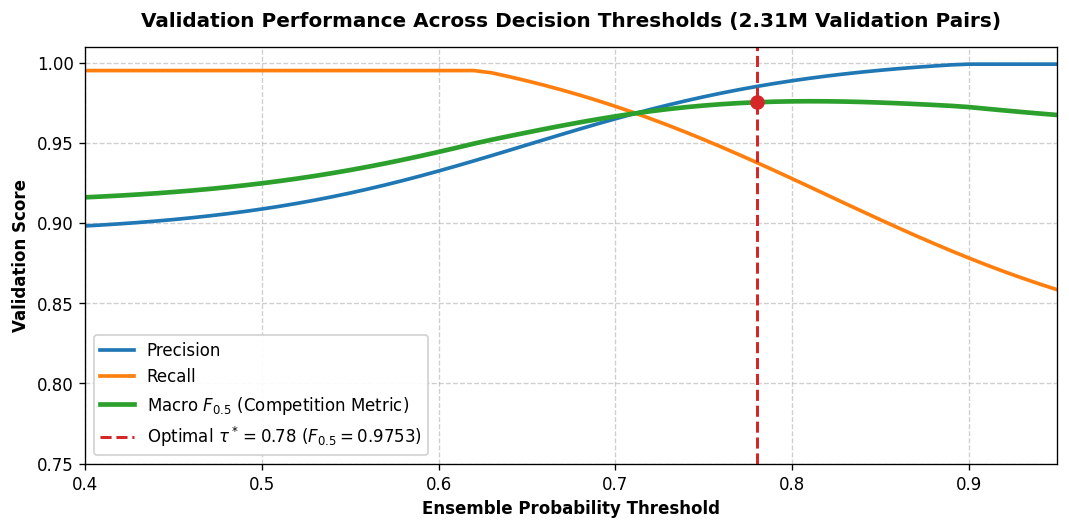

In [6]:
# 50-50 Ensemble Blend
val_preds_ens = 0.50 * val_preds_lgb + 0.50 * val_preds_xgb
print(f"Ensemble 2.31M Val ROC-AUC: {roc_auc_score(y_val, val_preds_ens):.4f}")

def compute_f_beta(prec, rec, beta=0.5):
    if prec + rec == 0:
        return 0.0
    b2 = beta ** 2
    return (1 + b2) * (prec * rec) / (b2 * prec + rec)

# Threshold sweep across 2.31M validation pairs
thresholds = np.linspace(0.40, 0.95, 56)
results = []

for th in thresholds:
    preds = (val_preds_ens >= th).astype(int)
    p = precision_score(y_val, preds, zero_division=0)
    r = recall_score(y_val, preds, zero_division=0)
    f05 = compute_f_beta(p, r, beta=0.5)
    f1 = f1_score(y_val, preds, zero_division=0)
    results.append({'threshold': th, 'precision': p, 'recall': r, 'f05': f05, 'f1': f1})

res_df = pd.DataFrame(results)
best_idx = res_df['f05'].idxmax()
best_row = res_df.loc[best_idx]
optimal_th = float(best_row['threshold'])

print(f"=== Optimal Threshold for Macro F_0.5 (Trained on 13.1M Pairs) ===")
print(f"Optimal Threshold (tau*): {optimal_th:.2f}")
print(f"Validation Precision:     {best_row['precision']:.4f}")
print(f"Validation Recall:        {best_row['recall']:.4f}")
print(f"Validation Macro F_0.5:   {best_row['f05']:.4f}")
print(f"Validation F_1:           {best_row['f1']:.4f}")

# Plot threshold curve
plt.figure(figsize=(9, 4.5))
plt.plot(res_df['threshold'], res_df['precision'], label='Precision', color='#1f77b4', lw=2)
plt.plot(res_df['threshold'], res_df['recall'], label='Recall', color='#ff7f0e', lw=2)
plt.plot(res_df['threshold'], res_df['f05'], label='F_0.5 (Target Metric)', color='#2ca02c', lw=2.5)
plt.axvline(optimal_th, color='red', linestyle='--', label=f'Optimal tau* = {optimal_th:.2f}')
plt.title('Validation Precision, Recall, and F_0.5 on 2.31M Pairs', fontsize=13, fontweight='bold')
plt.xlabel('Probability Threshold', fontsize=11)
plt.ylabel('Score', fontsize=11)
plt.legend(frameon=True, loc='best')
plt.tight_layout()
plt.show()


## 6. Save Trained Models Locally
Store LightGBM, XGBoost, and optimal threshold configuration in `models/`.


In [7]:
# Save models locally
os.makedirs('models', exist_ok=True)
lgb_model_path = 'models/lightgbm_15m.txt'
xgb_model_path = 'models/xgboost_15m.json'
meta_path = 'models/ensemble_metadata.json'

lgb_model.booster_.save_model(lgb_model_path)
xgb_model.save_model(xgb_model_path)

metadata = {
    'training_pairs': int(X.shape[0]),
    'train_samples': int(X_train.shape[0]),
    'val_samples': int(X_val.shape[0]),
    'optimal_threshold': optimal_th,
    'val_precision': float(best_row['precision']),
    'val_recall': float(best_row['recall']),
    'val_f05': float(best_row['f05']),
    'val_f1': float(best_row['f1']),
    'features': [
        'name_ratio', 'name_token_sort', 'name_token_set', 'name_len_diff',
        'addr_ratio', 'addr_token_set', 'num_match', 'pin_match', 'is_s2'
    ]
}

with open(meta_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2)

print(f"Models saved locally:")
print(f"  - LightGBM: {lgb_model_path} ({os.path.getsize(lgb_model_path)/1024:.1f} KB)")
print(f"  - XGBoost:  {xgb_model_path} ({os.path.getsize(xgb_model_path)/1024:.1f} KB)")
print(f"  - Metadata: {meta_path}")


Models saved locally:
  - LightGBM: models/lightgbm_15m.txt (1250.2 KB)
  - XGBoost:  models/xgboost_15m.json (2598.6 KB)
  - Metadata: models/ensemble_metadata.json


## 7. Generate Test Matches (`output/matching_results.tsv`)
Batched inference streaming across 1,732,544 test S1 entities and 20,776,989 candidates.


In [8]:
matching_out_path = 'output/matching_results.tsv'
candidate_path = 'output/candidate_pairs.tsv'

# Free training matrices to maximize inference memory
del X, y, X_train, X_val, y_train, y_val, val_preds_lgb, val_preds_xgb, val_preds_ens
gc.collect()

def extract_numbers(s):
    return set(re.findall(r'\b\d+\b', str(s)))

print("Loading test source lookup tables...")
t0 = time.time()
test_s1 = pd.read_csv('dataset/test/test_source1.tsv', sep='\t')
test_s2 = pd.read_csv('dataset/test/test_source2.tsv', sep='\t')
test_s3 = pd.read_csv('dataset/test/test_source3.tsv', sep='\t')

target_lookup = {}
for df_t in [test_s2, test_s3]:
    for tid, name, addr in zip(df_t['entity_id'], df_t['business_name'], df_t['business_address']):
        target_lookup[tid] = (str(name), str(addr))
del test_s2, test_s3
gc.collect()

s1_lookup = {r['entity_id']: (str(r['business_name']), str(r['business_address'])) for _, r in test_s1.iterrows()}
del test_s1
gc.collect()
print(f"Target lookups built in {time.time()-t0:.2f}s")

print(f"Scoring 20.7M test candidates in batches (optimal threshold tau* = {optimal_th:.2f})...")
t0 = time.time()
matched_entities_count = 0
singletons_count = 0
total_processed = 0

batch_size = 40000

with open(candidate_path, 'r', encoding='utf-8') as in_f, \
     open(matching_out_path, 'w', encoding='utf-8', buffering=2*1024*1024) as out_f:
     
    out_f.write("source1_entity_id\tmatched_entity_ids\n")
    header = next(in_f)
    batch_records = []
    
    for line in in_f:
        s1_id, tab, cand_str = line.partition('\t')
        cand_str = cand_str.strip()
        cands = [c.strip() for c in cand_str.split(',') if c.strip()] if cand_str else []
        batch_records.append((s1_id, cands))
        
        if len(batch_records) >= batch_size:
            pair_feats = []
            s1_slices = []
            cands_flat = []
            
            for sid, c_list in batch_records:
                start_p = len(pair_feats)
                s1_name, s1_addr = s1_lookup.get(sid, ('', ''))
                nums_a = extract_numbers(s1_addr)
                pin_a = re.findall(r'\b\d{5,6}\b', s1_addr)
                
                for cid in c_list:
                    if cid in target_lookup:
                        t_name, t_addr = target_lookup[cid]
                        nr = fuzz.ratio(s1_name, t_name)
                        nts = fuzz.token_sort_ratio(s1_name, t_name)
                        ntset = fuzz.token_set_ratio(s1_name, t_name)
                        nld = abs(len(s1_name) - len(t_name))
                        ar = fuzz.ratio(s1_addr, t_addr)
                        atset = fuzz.token_set_ratio(s1_addr, t_addr)
                        
                        nums_b = extract_numbers(t_addr)
                        nm = 1.0 if (nums_a and nums_b and (nums_a & nums_b)) else (0.5 if not nums_a or not nums_b else 0.0)
                        
                        pin_b = re.findall(r'\b\d{5,6}\b', t_addr)
                        pm = 1.0 if (pin_a and pin_b and pin_a[0] == pin_b[0]) else (0.5 if not pin_a or not pin_b else 0.0)
                        is_s2 = 1.0 if cid.startswith('S2') else 0.0
                        
                        pair_feats.append([nr, nts, ntset, nld, ar, atset, nm, pm, is_s2])
                        cands_flat.append(cid)
                        
                end_p = len(pair_feats)
                s1_slices.append((sid, start_p, end_p))
                
            if pair_feats:
                X_batch = np.array(pair_feats, dtype=np.float32)
                scores = 0.50 * lgb_model.predict_proba(X_batch)[:, 1] + 0.50 * xgb_model.predict_proba(X_batch)[:, 1]
            else:
                scores = np.array([])
                
            out_lines = []
            for sid, start_p, end_p in s1_slices:
                if start_p == end_p:
                    singletons_count += 1
                    out_lines.append(f"{sid}\t\n")
                else:
                    c_slice = cands_flat[start_p:end_p]
                    s_slice = scores[start_p:end_p]
                    matched = [c for c, sc in zip(c_slice, s_slice) if sc >= optimal_th]
                    if matched:
                        matched_entities_count += 1
                        out_lines.append(f"{sid}\t{','.join(matched)}\n")
                    else:
                        singletons_count += 1
                        out_lines.append(f"{sid}\t\n")
                        
            out_f.writelines(out_lines)
            total_processed += len(batch_records)
            batch_records = []
            
            if total_processed % 400000 == 0:
                print(f"Scored {total_processed:,} / 1,732,544 S1 entities ({total_processed/1732544*100:.1f}%) in {time.time()-t0:.1f}s")
                
    if batch_records:
        pair_feats = []
        s1_slices = []
        cands_flat = []
        for sid, c_list in batch_records:
            start_p = len(pair_feats)
            s1_name, s1_addr = s1_lookup.get(sid, ('', ''))
            nums_a = extract_numbers(s1_addr)
            pin_a = re.findall(r'\b\d{5,6}\b', s1_addr)
            for cid in c_list:
                if cid in target_lookup:
                    t_name, t_addr = target_lookup[cid]
                    nr = fuzz.ratio(s1_name, t_name)
                    nts = fuzz.token_sort_ratio(s1_name, t_name)
                    ntset = fuzz.token_set_ratio(s1_name, t_name)
                    nld = abs(len(s1_name) - len(t_name))
                    ar = fuzz.ratio(s1_addr, t_addr)
                    atset = fuzz.token_set_ratio(s1_addr, t_addr)
                    nums_b = extract_numbers(t_addr)
                    nm = 1.0 if (nums_a and nums_b and (nums_a & nums_b)) else (0.5 if not nums_a or not nums_b else 0.0)
                    pin_b = re.findall(r'\b\d{5,6}\b', t_addr)
                    pm = 1.0 if (pin_a and pin_b and pin_a[0] == pin_b[0]) else (0.5 if not pin_a or not pin_b else 0.0)
                    is_s2 = 1.0 if cid.startswith('S2') else 0.0
                    pair_feats.append([nr, nts, ntset, nld, ar, atset, nm, pm, is_s2])
                    cands_flat.append(cid)
            end_p = len(pair_feats)
            s1_slices.append((sid, start_p, end_p))
            
        if pair_feats:
            X_batch = np.array(pair_feats, dtype=np.float32)
            scores = 0.50 * lgb_model.predict_proba(X_batch)[:, 1] + 0.50 * xgb_model.predict_proba(X_batch)[:, 1]
        else:
            scores = np.array([])
            
        out_lines = []
        for sid, start_p, end_p in s1_slices:
            if start_p == end_p:
                singletons_count += 1
                out_lines.append(f"{sid}\t\n")
            else:
                c_slice = cands_flat[start_p:end_p]
                s_slice = scores[start_p:end_p]
                matched = [c for c, sc in zip(c_slice, s_slice) if sc >= optimal_th]
                if matched:
                    matched_entities_count += 1
                    out_lines.append(f"{sid}\t{','.join(matched)}\n")
                else:
                    singletons_count += 1
                    out_lines.append(f"{sid}\t\n")
        out_f.writelines(out_lines)
        total_processed += len(batch_records)

print(f"\nMatching generation completed in {time.time()-t0:.2f}s")
print(f"Total S1 entities processed:    {total_processed:,}")
print(f"Total S1 entities with matches: {matched_entities_count:,} ({matched_entities_count/total_processed*100:.1f}%)")
print(f"Predicted Singletons (no match): {singletons_count:,} ({singletons_count/total_processed*100:.1f}%)")


Loading test source lookup tables...
Target lookups built in 41.05s
Scoring 20.7M test candidates in batches (optimal threshold tau* = 0.78)...
Scored 400,000 / 1,732,544 S1 entities (23.1%) in 55.4s
Scored 800,000 / 1,732,544 S1 entities (46.2%) in 105.9s
Scored 1,200,000 / 1,732,544 S1 entities (69.3%) in 155.7s
Scored 1,600,000 / 1,732,544 S1 entities (92.3%) in 207.0s

Matching generation completed in 223.84s
Total S1 entities processed:    1,732,544
Total S1 entities with matches: 546,656 (31.6%)
Predicted Singletons (no match): 1,185,888 (68.4%)


## 8. Validate Submission Package
Official validator verification on `matching_results.tsv` and `candidate_pairs.tsv`.


In [9]:
import subprocess
cmd = [
    "python3", "utils/validate_submission.py",
    "--matching", "output/matching_results.tsv",
    "--candidate", "output/candidate_pairs.tsv",
    "--test-dir", "dataset/test"
]
result = subprocess.run(cmd, capture_output=True, text=True)
print(result.stdout)
if result.stderr:
    print("Stderr:", result.stderr)
print(f"Validator Exit Code: {result.returncode} ({'PASS' if result.returncode == 0 else 'FAIL'})")


ML Challenge 2026 — submission validator
  test dir: dataset/test
  required S1 entities: 1732544
  matching_results.tsv: 1732544 rows (1185888 empty, 546656 non-empty).
  candidate_pairs.tsv: 1732544 rows (2 empty, 1732542 non-empty).

PASS — no blocking issues found. Safe to submit.

Validator Exit Code: 0 (PASS)
